# XGBoost

## 1.Bibliotecas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from pathlib import Path
import time

from scipy.stats import ttest_rel

# sklearn
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             average_precision_score,roc_curve)

from sklearn.base import BaseEstimator, TransformerMixin, clone

# Importações locais
from setup_notebook import setup_path
setup_path()
from src.model_utils import *
from src.preprocess_utils_diab3 import * #(NOVO atualizações)
from src.plot_metrica_class import *

print("\n#Processo iniciado em:", time.strftime("%H:%M:%S"))
start_inicial = time.time()


#Processo iniciado em: 16:37:55


## 2. Dataload & Preprocessamento com joblib


In [2]:
BASE = Path.cwd().parent   
# =====================================================
# ⚙️ 0. carregamento dos preprocessador 
# =====================================================
PP3 = joblib.load(BASE/'src'/'preprocess_diabetes_v3.joblib')['preprocessador']

# # =====================================================
# # 📁 1. Leitura dos dados & Separação das bases
# # =====================================================

DATA_DIR = BASE / "data" / "raw"
X_train = pd.read_csv(DATA_DIR / "X_train_raw.csv").reset_index(drop=True)
X_val  = pd.read_csv(DATA_DIR / "X_test_raw.csv")
y_train = pd.read_csv(DATA_DIR / "y_train_raw.csv").values.ravel()
y_val  = pd.read_csv(DATA_DIR / "y_test_raw.csv")
mtd_scoring='roc_auc'

# # # =====================================================
# # #  🤖 3.Definição dos Modelos
# # # =====================================================
model_XGB0 = XGBClassifier(objective='binary:logistic',eval_metric='logloss',enable_categorical=True,
                           tree_method="hist" , random_state=42)
pipe_XGB0      = pipe_models(model_XGB0,PP3)


DATA_MODELS= BASE /"models"
pipe_XGB1 = joblib.load(DATA_MODELS / 'modelo_XGB2_final_randsearch.roc_auc_v3.joblib')
pipe_XGB2 = joblib.load(DATA_MODELS / 'modelo_XGB2_final_refine.roc_auc_v3.joblib')
print("\n#Processo iniciado em:", time.strftime("%H:%M:%S"))


#Processo iniciado em: 16:37:57


## 3. Modelos
### 3.1 Baseline

In [3]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R0=evaluate_model(pipe_XGB0,X_train,y_train,X_val,y_val,modelname='Baseline')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R0['y_pred'][0]))
cm=confusion_matrix(y_val, R0['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 16:37:57

                         📍 RESULTADOS BASELINE                        
📊 CROSS-VALIDATION
   Média roc_auc:                0.7207 ± 0.0015

✅ TEST SET
   Padrão (0.5):                  0.6818
   Otimizado:                     0.6815 (threshold = 0.510)
   ROC-AUC:                       0.7228
   Avg precision:                 0.8084
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.61      0.42      0.50     79108
         1.0       0.71      0.84      0.77    130892

    accuracy                           0.68    210000
   macro avg       0.66      0.63      0.63    210000
weighted avg       0.67      0.68      0.67    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         33600       45508      
Real 1         21308       109584     
────────────────────────────────────────────────────────

### 3.2 Modelo 1

In [4]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R1=evaluate_model(pipe_XGB1,X_train,y_train,X_val,y_val,modelname='XGB 1')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R1['y_pred'][0]))
cm=confusion_matrix(y_val, R1['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 16:38:24

                          📍 RESULTADOS XGB 1                          
📊 CROSS-VALIDATION
   Média roc_auc:                0.7271 ± 0.0013

✅ TEST SET
   Padrão (0.5):                  0.6856
   Otimizado:                     0.6853 (threshold = 0.510)
   ROC-AUC:                       0.7272
   Avg precision:                 0.8118
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.62      0.43      0.51     79108
         1.0       0.71      0.84      0.77    130892

    accuracy                           0.69    210000
   macro avg       0.66      0.64      0.64    210000
weighted avg       0.68      0.69      0.67    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         34305       44803      
Real 1         21231       109661     
────────────────────────────────────────────────────────

### 3.3 Modelo 2

In [5]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R2=evaluate_model(pipe_XGB2,X_train,y_train,X_val,y_val,modelname='XGB 2')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R2['y_pred'][0]))
cm=confusion_matrix(y_val, R2['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")


#Processo iniciado em: 16:41:37

                          📍 RESULTADOS XGB 2                          
📊 CROSS-VALIDATION
   Média roc_auc:                0.7270 ± 0.0013

✅ TEST SET
   Padrão (0.5):                  0.6849
   Otimizado:                     0.6849 (threshold = 0.500)
   ROC-AUC:                       0.7272
   Avg precision:                 0.8118
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.62      0.43      0.51     79108
         1.0       0.71      0.84      0.77    130892

    accuracy                           0.68    210000
   macro avg       0.66      0.63      0.64    210000
weighted avg       0.67      0.68      0.67    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         34208       44900      
Real 1         21263       109629     
────────────────────────────────────────────────────────

## 4 Relatorio de Classificação

In [6]:
# =====================================================
# A. Avaliação comparativa dos modelos RF (Baseline)
# =====================================================
# Nesta etapa é realizada uma análise comparativa completa entre os
# modelos testados. O objetivo é avaliar
# desempenho, estabilidade e diferença estatística entre os modelos.
# Calcula os scores de validação cruzada para cada modelo(roc-auc)

# -----------------------------------------------------
# A.1 Validação cruzada ROC-AUC & acuraccy
# -----------------------------------------------------

s0_auc = R0['cv_scores'][0]
s1_auc = R1['cv_scores'][0]
s2_auc = R2['cv_scores'][0]

cv_s = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


print(f"Iniciando Cross-Validation Accuracy ...")
start_m = time.time()
s0_acc = cross_val_score(pipe_XGB0, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ Baseline - ⏱️ {time.time() - start_m:5.2f}s")
start_m = time.time()
s1_acc = cross_val_score(pipe_XGB1, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ modelo 1 - ⏱️ {time.time() - start_m:5.2f}s")
start_m = time.time()
s2_acc = cross_val_score(pipe_XGB2, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ modelo 2 - ⏱️ {time.time() - start_m:5.2f}s")

# -----------------------------------------------------
# A.2 Probabilidades no conjunto de teste
# -----------------------------------------------------
y_prob0 = R0['y_probs'][0]
y_prob1 = R1['y_probs'][0]
y_prob2 = R2['y_probs'][0]

# -----------------------------------------------------
# A.4 Estrutura dos dados para relatorio
# -----------------------------------------------------
models_list = [
    ('Modelo 0  (base)' , pipe_XGB0, s0_auc, s0_acc, y_prob0,R0['best_t'][0]),
    ('Modelo 1  (base)' , pipe_XGB0, s0_auc, s0_acc, y_prob0, R0['best_t'][0]),
    ('Modelo 2  (exp) ', pipe_XGB1, s1_auc, s1_acc, y_prob1   ,R1['best_t'][0]),
    ('Modelo 3  (ref) ', pipe_XGB2, s2_auc, s2_acc, y_prob2   , R2['best_t'][0])
]
# -----------------------------------------------------
# A.5 Geração do relatório estatístico
# -----------------------------------------------------

print(f" Construindo relatorio ...")
df_results,W = gerar_relatorio_estatistico2(models_list,X_train, y_train,X_val, y_val)

Iniciando Cross-Validation Accuracy ...
    ✅ Baseline - ⏱️ 10.83s
    ✅ modelo 1 - ⏱️ 102.73s
    ✅ modelo 2 - ⏱️ 96.98s
 Construindo relatorio ...
                      RELATÓRIO DE DESEMPENHO E ESTABILIDADE ESTATÍSTICA                       
          Modelo  CV ROC Mean  CV ROC Std  CV ACC Mean  CV ACC Std  Test ROC-AUC  Test ACC (0.5)  Best Thresh  Test ACC (Opt)
Modelo 0  (base)       0.7207      0.0015       0.6805      0.0014        0.7228          0.6818         0.51          0.6815
Modelo 1  (base)       0.7207      0.0015       0.6805      0.0014        0.7228          0.6818         0.51          0.6815
Modelo 2  (exp)        0.7271      0.0013       0.6846      0.0012        0.7272          0.6856         0.51          0.6853
Modelo 3  (ref)        0.7270      0.0013       0.6845      0.0010        0.7272          0.6849         0.50          0.6849

                     ANÁLISE DE SIGNIFICÂNCIA ESTATÍSTICA (T-TEST PAREADO)                     
Modelo 1  (base) vs Modelo 2

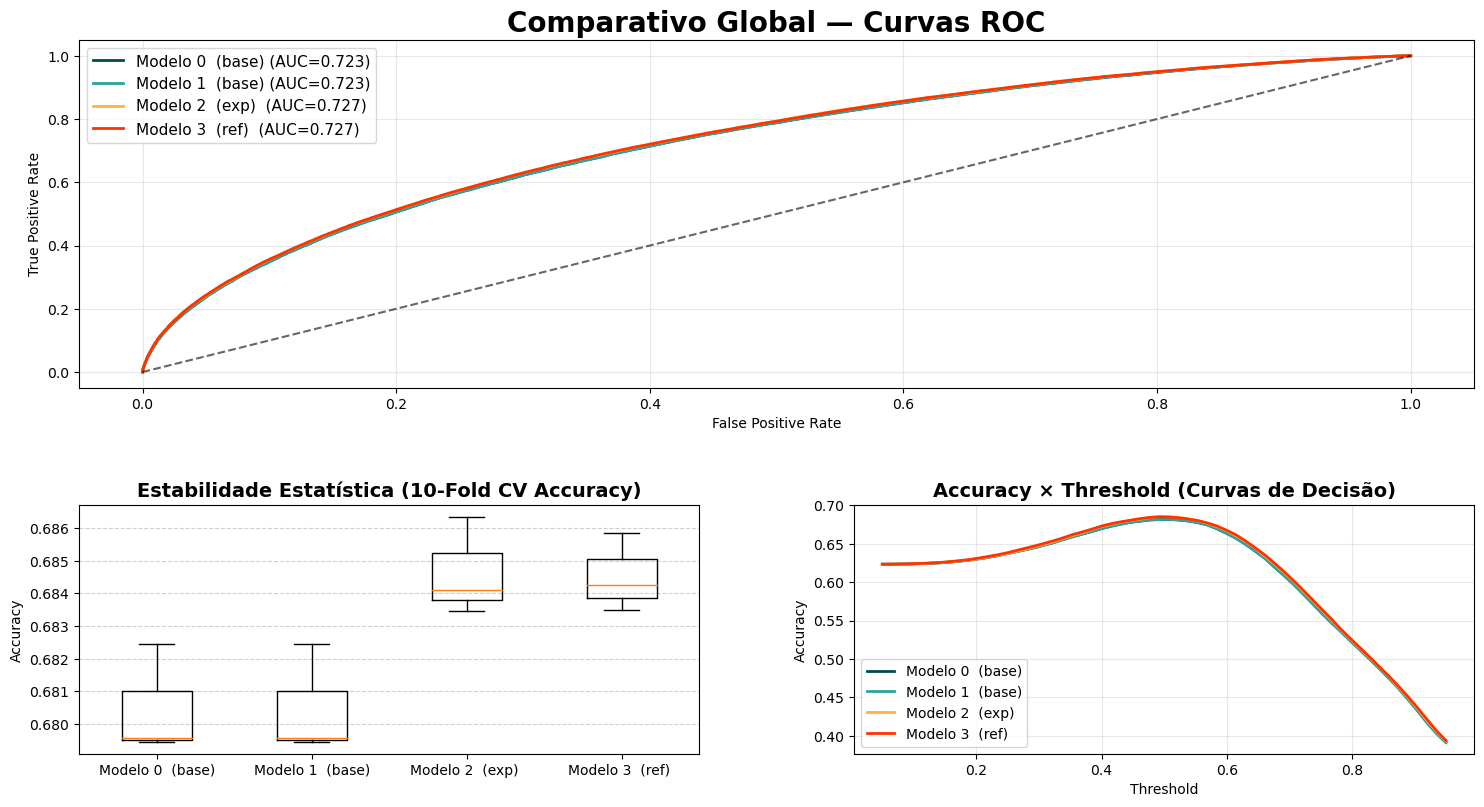

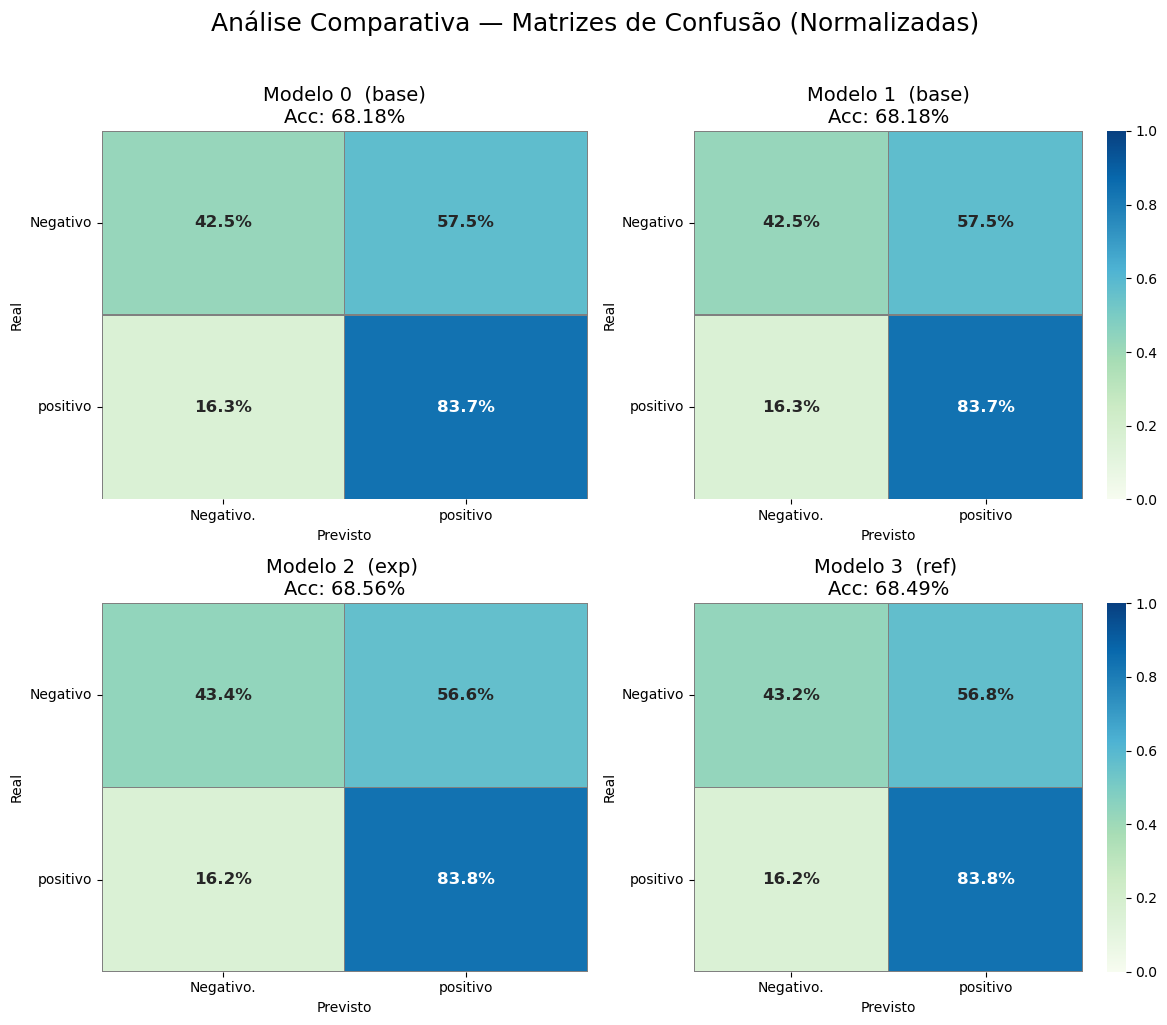

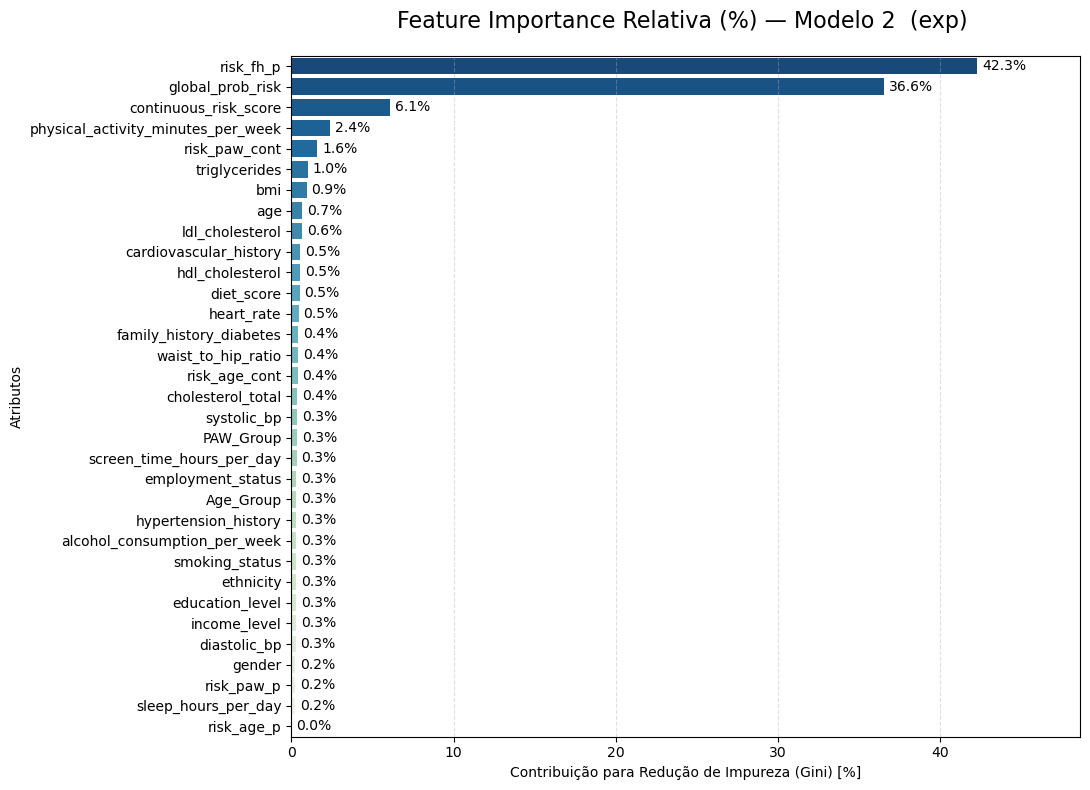


#Processo finalizado em: 16:48:10


In [7]:
#plotagem dos resultados
importances=model_evaluation_grid(
    models_list=models_list,
    X_test=X_val,
    y_test=y_val,
    best_model_pipeline=W[1],
    best_model_name=W[0]
)